In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df_orginal = pd.read_csv("./data/IMDB Dataset.csv")
df = df_orginal.copy(deep=True)

In [3]:
print(df.columns.to_list())

['review', 'sentiment']


In [4]:
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [6]:
print(df.describe(include='all')) # include='all' : to summarize categoriacal (object) data 

                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000


In [7]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [8]:
print(df["review"].value_counts())

review
Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Very stimulating and captivating, always keeping the viewer peeking around the corner to see what was coming up next. She is as down to earth and as personable as you get, like one of us which made the show all the more enjoyable. Special guests, who are friends as well made for a nice surprise too. Loved the 'first' theme and that the audience was invited to play along too. I must admit I was shocked to see her come in under her time limits on a few things, but she did it and by golly I'll be writing those recipes down. Saving time in the kitchen means more time with family. Those who haven't tuned in yet, find out what channel and the time, I assure you that you won't be disappointed.                                                                                                                                                                                                         

## Descriptive Statistics :

In [9]:
df["review_char_len"] = df["review"].apply(len)
df["review_word_len"] = df["review"].apply(lambda x : len(x.split())) # Generally slows for large dataset so use the below statement
# df["review_word_len"] = [len(str(x).split()) for x in df["review"]]

print(df[["review_char_len","review_word_len"]].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


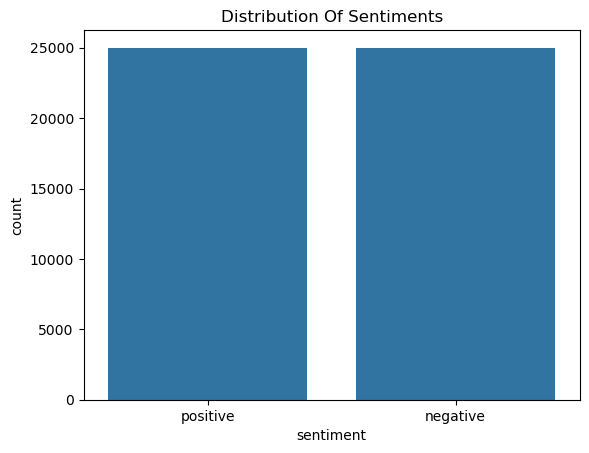

In [10]:
# Sentiment Distribution :
sns.countplot(x="sentiment",data=df)
plt.title("Distribution Of Sentiments")
plt.show()

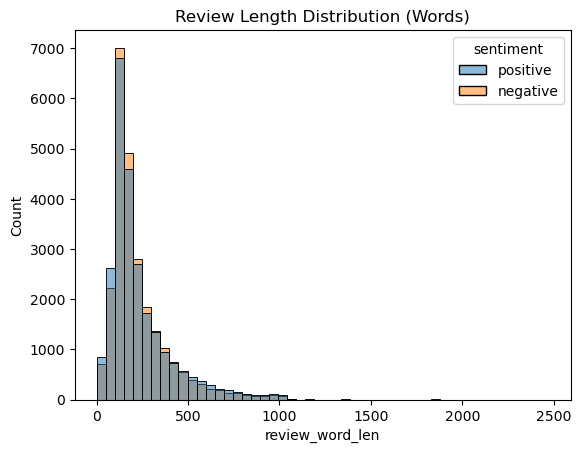

In [11]:
# Histogram Distribution Review Word length
sns.histplot(data=df,x="review_word_len",bins=50,hue="sentiment",kde=False)
plt.title("Review Length Distribution (Words)")
plt.show()

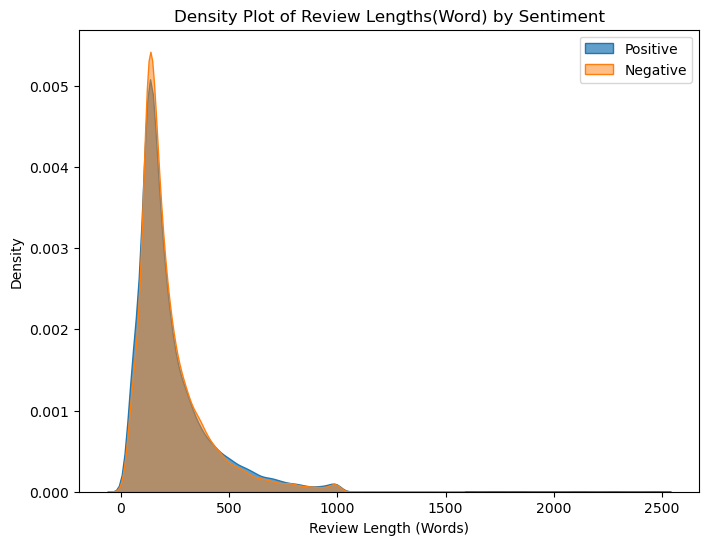

In [12]:
# Kdeplot(Density Plot) of Review word length :
plt.figure(figsize=(8,6))
sns.kdeplot(data=df[df["sentiment"]=="positive"]["review_word_len"],label="Positive",fill=True,alpha=0.7)
sns.kdeplot(data=df[df["sentiment"]=="negative"]["review_word_len"],label="Negative",fill=True,alpha=0.5)
plt.title("Density Plot of Review Lengths(Word) by Sentiment")
plt.xlabel("Review Length (Words)")
plt.ylabel("Density")
plt.legend()
plt.show()


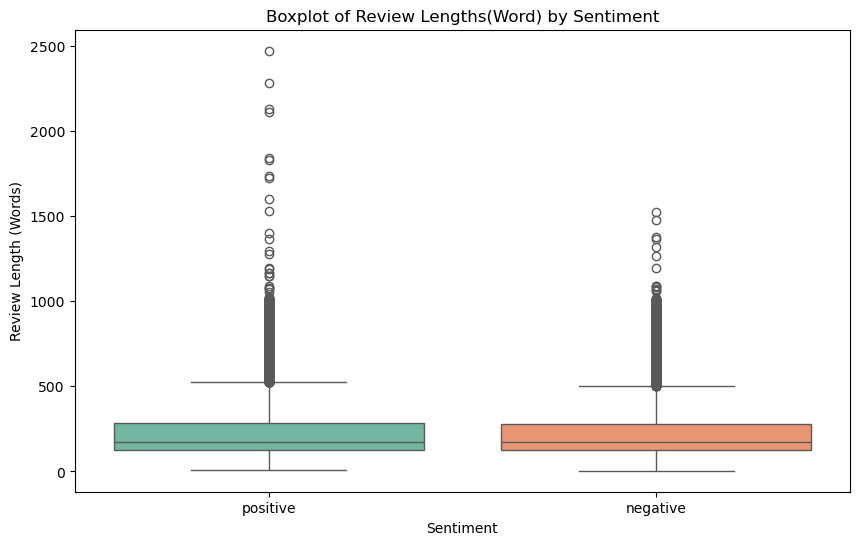

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="sentiment", y="review_word_len", palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths(Word) by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")
plt.show()

In [14]:
import numpy as np
def outliers_detection(data,col):
    Q1 = np.quantile(data[col],0.25)
    Q3 = np.quantile(data[col],0.75)
    IQR = Q3-Q1
    lower = Q1-(1.5*IQR)
    upper = Q3+(1.5*IQR)
    outliers = data[(data[col]<lower) | (data[col]>upper)]
    return lower,upper,outliers[[col]]

lower,upper,outliers=outliers_detection(df,"review_word_len")
print(f"Number of outliers : {outliers.shape[0]}")
# print(lower,upper)

Number of outliers : 3708


In [15]:
df_clean_iqr = df[(df["review_word_len"]>=lower) & (df["review_word_len"]<=upper)]
print(f"Orginal data : {df.shape[0]}")
print(f"Cleaned data : {df_clean_iqr.shape[0]}")
# outliers.shape[0]+df_clean_iqr.shape[0] # just checking my df_clean_iqr is correct or not

Orginal data : 50000
Cleaned data : 46292


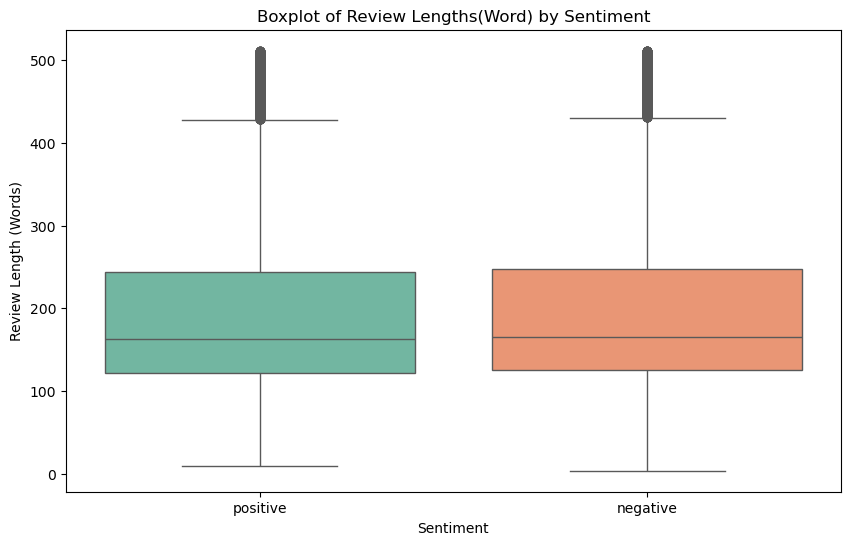

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean_iqr, x="sentiment", y="review_word_len", palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths(Word) by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")
plt.show()

## Most Common words Positive vs Negative :
###### make sure that you have installed nltk library 
- !pip install nltk

In [17]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

In [18]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
# stop_word : type(set) and length = 198

[nltk_data] Downloading package stopwords to C:\Users\SUSHIL KUMAR
[nltk_data]     SAHOO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
def preprocess_text(text):
    # remove all non-alphabetic characters and convert to lower case 
    words = re.findall(r'\b[a-z]+\b', text.lower()) 
    return [w for w in words if w not in stop_words and w!='br']

In [20]:
pos_reviews = df[df["sentiment"]=="positive"]["review"].apply(preprocess_text)
neg_reviews = df[df["sentiment"]=="negative"]["review"].apply(preprocess_text)
# print(type(pos_reviews)) <class 'pandas.core.series.Series'>

In [21]:
pos_word = [word for review in pos_reviews for word in review]
neg_word = [word for review in neg_reviews for word in review]
# print(pos_word)

In [22]:
# pos_word

In [23]:
pos_common = Counter(pos_word).most_common(20)
neg_common = Counter(neg_word).most_common(20)
print(f"Top 20 postive words : {pos_common}")
print(f"Top 20 negative words : {neg_common}")

Top 20 postive words : [('film', 42110), ('movie', 37854), ('one', 27320), ('like', 17714), ('good', 15025), ('great', 12964), ('story', 12934), ('time', 12752), ('well', 12729), ('see', 12276), ('also', 10793), ('really', 10739), ('would', 10595), ('even', 9617), ('first', 9230), ('much', 9201), ('people', 8719), ('love', 8692), ('best', 8510), ('get', 8285)]
Top 20 negative words : [('movie', 50117), ('film', 37595), ('one', 26283), ('like', 22458), ('even', 15254), ('good', 14728), ('bad', 14726), ('would', 14007), ('time', 12358), ('really', 12355), ('see', 10753), ('story', 10185), ('get', 10136), ('much', 10117), ('people', 9469), ('make', 9355), ('could', 9300), ('made', 8801), ('well', 8539), ('first', 8353)]


In [24]:
from sklearn.feature_extraction.text import CountVectorizer
def get_top_ngrams(word_list,ngram_range=(2,2),top_n=10):
    vec = CountVectorizer(ngram_range=ngram_range)
    bag = vec.fit_transform([' '.join(word_list)])
    sum_words = bag.sum(axis=0) 
    word_freq = [(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    sorted_words = sorted(word_freq,key=lambda x:x[1],reverse=True)
    return sorted_words[:top_n]    

In [25]:
print(f"Top positive bigrams :{get_top_ngrams(pos_word,(2,2))}")
print(f"Top negative bigrams :{get_top_ngrams(neg_word,(2,2))}")

Top positive bigrams :[('one best', np.int64(1680)), ('even though', np.int64(1099)), ('ever seen', np.int64(976)), ('first time', np.int64(960)), ('new york', np.int64(855)), ('special effects', np.int64(806)), ('see movie', np.int64(784)), ('must see', np.int64(778)), ('real life', np.int64(761)), ('years ago', np.int64(741))]
Top negative bigrams :[('ever seen', np.int64(1734)), ('special effects', np.int64(1443)), ('waste time', np.int64(1437)), ('looks like', np.int64(1234)), ('low budget', np.int64(1229)), ('much better', np.int64(1009)), ('one worst', np.int64(964)), ('look like', np.int64(945)), ('bad movie', np.int64(927)), ('year old', np.int64(914))]


In [26]:
print(f"Top positive trigrams :{get_top_ngrams(pos_word,(3,3))}")
print(f"Top negative trigrams :{get_top_ngrams(neg_word,(3,3))}")

Top positive trigrams :[('new york city', np.int64(195)), ('world war ii', np.int64(167)), ('one best movies', np.int64(144)), ('based true story', np.int64(135)), ('movie ever seen', np.int64(134)), ('one best films', np.int64(132)), ('first time saw', np.int64(115)), ('movies ever seen', np.int64(112)), ('films ever made', np.int64(99)), ('well worth watching', np.int64(95))]
Top negative trigrams :[('worst movie ever', np.int64(459)), ('movie ever seen', np.int64(394)), ('one worst movies', np.int64(311)), ('worst movies ever', np.int64(282)), ('movies ever seen', np.int64(268)), ('worst film ever', np.int64(202)), ('waste time money', np.int64(181)), ('one worst films', np.int64(169)), ('film ever seen', np.int64(166)), ('movie ever made', np.int64(155))]


In [27]:
# !pip install wordcloud 

In [28]:
from wordcloud import WordCloud

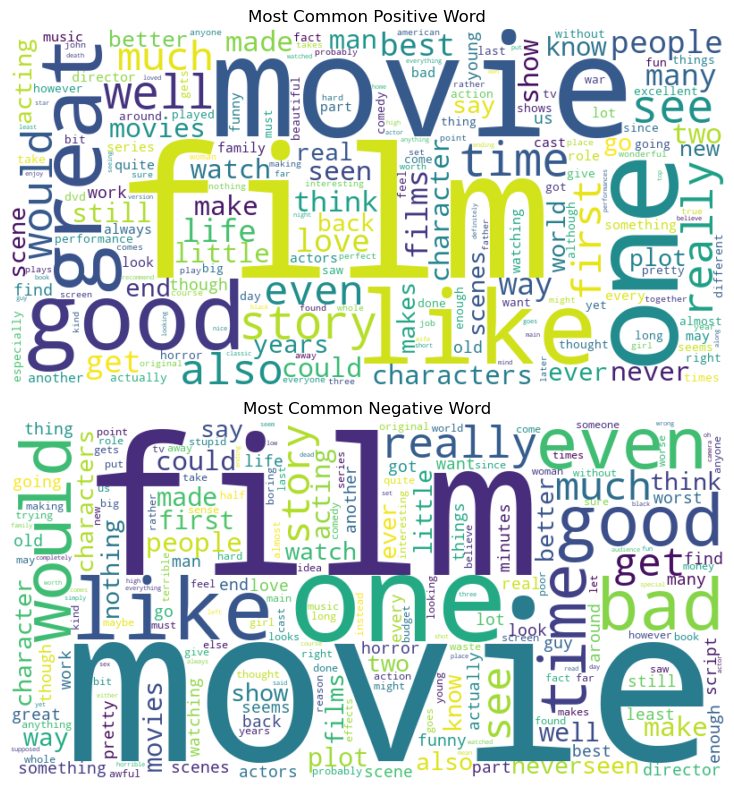

In [29]:
pos_common_300 = Counter(pos_word).most_common(300)
neg_common_300 = Counter(neg_word).most_common(300)

pos_word_dict = dict(pos_common_300)
neg_word_dict = dict(neg_common_300)

# generate a word cloud for positive words
pos_word_cloud = WordCloud(height=400,width=800,background_color='white').generate_from_frequencies(pos_word_dict)

# generate a word cloud for negative words
neg_word_cloud = WordCloud(height=400,width=800,background_color='white').generate_from_frequencies(neg_word_dict) 

plt.figure(figsize=(20,8))

plt.subplot(2,1,1)
plt.imshow(pos_word_cloud,interpolation='bilinear')
plt.title("Most Common Positive Word")
plt.axis('off')
plt.subplot(2,1,2)
plt.imshow(neg_word_cloud,interpolation='bilinear')
plt.title("Most Common Negative Word")
plt.axis('off')

plt.tight_layout()
plt.show()

### Inferential Statistics :

In [30]:
df.columns

Index(['review', 'sentiment', 'review_char_len', 'review_word_len'], dtype='object')

In [31]:
from scipy.stats import ttest_ind

# Split the review lengths by sentiment :
pos_length = df[df['sentiment']=='positive']['review_word_len']
neg_length = df[df['sentiment']=='negative']['review_word_len']

# Two sample hypothesis test :
# Performs independent sample t-test :
# H0 - Average review lengths (in words) is the same for positive and negative reviews 
# H1 - Average review lengths (in words) is different between positive and negative reviews
t_test,p_val = ttest_ind(pos_length,neg_length,equal_var=False)

print("T-statistics :",t_test)
print("P value :",p_val)

# mean of the positive and negative review 
print("Mean Words (positive reviews) :",pos_length.mean())
print("Mean Words (negative reviews) :",neg_length.mean())

print("Median words (positive reviews) :",pos_length.median())
print("Median words (negative reviews) :",neg_length.median())

T-statistics : 2.2086700126903724
P value : 0.027202144656625776
Mean Words (positive reviews) : 232.84932
Mean Words (negative reviews) : 229.46456
Median words (positive reviews) : 172.0
Median words (negative reviews) : 174.0


- Conclusion : Since p_val < 0.05 So we reject H0 average review length is different 
- But check the descriptive stats : it's saying there is a very very small differece which is considered as there is no difference between
                               <br>  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  pos_review_word_len & neg_review_word_len 

- *Remember : Hypothesis testing is always done on samples ,but on the above i have done it on whole population so the p_val is there comes
 <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;           less than 0.05 , which directs the whole decission in a wrong way

In [32]:
df_subset = df.sample(n=1000,random_state=42)

# Split the review lengths by sentiment :
pos_length_subset = df_subset[df_subset['sentiment']=='positive']['review_word_len']
neg_length_subset = df_subset[df_subset['sentiment']=='negative']['review_word_len']

# Two sample hypothesis test :
# Performs independent sample t-test :
# H0 - Average review lengths (in words) is the same for positive and negative reviews 
# H1 - Average review lengths (in words) is different between positive and negative reviews
t_test,p_val = ttest_ind(pos_length_subset,neg_length_subset,equal_var=False)

print("T-statistics :",t_test)
print("P value :",p_val)

# mean of the positive and negative review 
print("Mean Words (positive reviews) :",pos_length_subset.mean())
print("Mean Words (negative reviews) :",neg_length_subset.mean())

print("Median words (positive reviews) :",pos_length_subset.median())
print("Median words (negative reviews) :",neg_length_subset.median())

T-statistics : -0.9691994768177146
P value : 0.33268051909807894
Mean Words (positive reviews) : 228.18487394957984
Mean Words (negative reviews) : 238.84923664122138
Median words (positive reviews) : 176.0
Median words (negative reviews) : 177.5


- Now the p value (> 0.05) So we fail to reject H0 that means the average length of positive & negative reviews are same

In [35]:
# Chi-Sqare Test : categorical data
from scipy.stats import chi2_contingency

# Extracting categorical data
df_subset["review_word_cat"] = df["review_word_len"].apply(lambda x: 'short' if x<=100 else 'long')
contigency = pd.crosstab(df_subset['review_word_cat'],df_subset['sentiment'],margins=True)
print("Contigency Table :\n",contigency)
# contigency table : is the frequency distribution table which displays relationship between categorical varibales

chi_test,p_val,_,_ = chi2_contingency(contigency)
print("\nChi-sqare Test :",chi_test)
print("p value :",p_val)

Contigency Table :
 sentiment        negative  positive   All
review_word_cat                          
long                  457       409   866
short                  67        67   134
All                   524       476  1000

Chi-sqare Test : 0.35733137462802034
p value : 0.9858188512442948


- On the above chi-test p value is again (> 0.05) so there we are again failed to reject H0